In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.7 MB/s eta 0:00:00


In [3]:
import copy

import torch

import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv
from torch_geometric.utils import to_dense_adj

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type != 'cuda':
    raise RuntimeError(
        "CUDA GPU not detected. In Colab, set Runtime -> Change runtime type -> Hardware accelerator -> GPU, then reconnect and rerun."
    )

torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = True
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.allow_tf32 = True

cuda_version = torch.version.cuda.replace('.', '')
device_suffix = f'cu{cuda_version}'
torch_version = torch.__version__.split('+')[0]

print(f"Detected PyTorch version: {torch_version}")
print(f"Using GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA wheel suffix: {device_suffix}")

wheel_index_url = f"https://data.pyg.org/whl/torch-{torch_version}+{device_suffix}.html"

!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv -f {wheel_index_url}
!pip install -q torch-geometric

Detected PyTorch version: 2.10.0
Using GPU: NVIDIA L4
CUDA wheel suffix: cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.5 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 35.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.9 MB/s eta 0:00:00


In [5]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

Processing...
Done!


In [6]:
#GAT implementation using the GATConv layer from PyG
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads):
        super().__init__()
        # First layer: multi-head attention (8 heads is the paper standard for Cora)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        # Second layer: output layer (averaging heads for classification)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GAT(dataset.num_features, 8, dataset.num_classes, heads=8).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

for epoch in range(200):
    loss = train()
    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}')

model.eval()
pred = model(data.x, data.edge_index).argmax(dim=1)
acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
print(f'Test Accuracy: {acc:.4f}')

Epoch 000, Loss: 1.9258
Epoch 020, Loss: 0.9159
Epoch 040, Loss: 0.6275
Epoch 060, Loss: 0.4623
Epoch 080, Loss: 0.4976
Epoch 100, Loss: 0.4251
Epoch 120, Loss: 0.4148
Epoch 140, Loss: 0.4097
Epoch 160, Loss: 0.3282
Epoch 180, Loss: 0.2907
Test Accuracy: 0.7900


In [7]:
import torch.nn as nn

In [8]:
# Custom GAT Implementation (Without PyG)
class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout, alpha, concat=True, gain=1.414):
        super(GATLayer, self).__init__()
        self.dropout = dropout
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        self.concat = concat

        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=gain)

        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=gain)

        self.leakyrelu = nn.LeakyReLU(self.alpha)

    def forward(self, h, adj):
        Wh = torch.mm(h, self.W)
        N = Wh.size()[0]

        a_input = torch.cat([Wh.repeat_interleave(N, dim=0), Wh.repeat(N, 1)], dim=1)
        a_input = a_input.view(N, N, 2 * self.out_features)
        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))

        zero_vec = -1e9 * torch.ones_like(e) # Using -1e9 for better stability
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)

        h_prime = torch.matmul(attention, Wh)

        if self.concat:
            return F.elu(h_prime)
        else:
            return h_prime

class GAT_Model(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout, alpha, nheads):
        super(GAT_Model, self).__init__()
        self.dropout = dropout

        self.attentions = nn.ModuleList([
            GATLayer(nfeat, nhid, dropout=dropout, alpha=alpha, concat=True, gain=1.414)
            for _ in range(nheads)
        ])

        self.out_att = GATLayer(nhid * nheads, nclass, dropout=dropout, alpha=alpha, concat=False, gain=1.0)

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)

        x = torch.cat([att(x, adj) for att in self.attentions], dim=1)

        x = F.dropout(x, self.dropout, training=self.training)

        x = self.out_att(x, adj)

        return F.log_softmax(x, dim=1)

In [9]:
adj = to_dense_adj(data.edge_index)[0].to(device)
adj = adj + torch.eye(adj.size(0), device=adj.device)
features = data.x.to(device)
labels = data.y.to(device)

model = GAT_Model(
    nfeat=dataset.num_features,
    nhid=8,
    nclass=dataset.num_classes,
    dropout=0.6,
    alpha=0.2,
    nheads=8
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [10]:
PATIENCE = 200
MAX_EPOCHS = 2000

In [11]:
NUM_RUNS = 10
all_run_test_accs = []
absolute_best_test_acc = 0
absolute_best_state = None

print(f"Starting {NUM_RUNS} independent runs to reproduce paper results...")

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

for run in range(NUM_RUNS):
    model = GAT_Model(
        nfeat=dataset.num_features,
        nhid=8,
        nclass=dataset.num_classes,
        dropout=0.6,
        alpha=0.2,
        nheads=8
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

    best_val_acc = 0
    run_best_model_state = None
    bad_counter = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        out = model(features, adj)
        loss = F.nll_loss(out[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(features, adj)
            val_pred = logits.argmax(dim=1)
            val_acc = (val_pred[val_mask] == labels[val_mask]).sum().item() / val_mask.sum().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            bad_counter = 0
            run_best_model_state = copy.deepcopy(model.state_dict())
        else:
            bad_counter += 1

        if bad_counter == PATIENCE:
            break

    model.load_state_dict(run_best_model_state)
    model.eval()
    with torch.no_grad():
        logits = model(features, adj)
        test_pred = logits.argmax(dim=1)
        test_acc = (test_pred[test_mask] == labels[test_mask]).sum().item() / test_mask.sum().item()

    all_run_test_accs.append(test_acc)
    print(f"Run {run+1}/{NUM_RUNS} | Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if test_acc > absolute_best_test_acc:
        absolute_best_test_acc = test_acc
        absolute_best_state = run_best_model_state

print("\n--- Final Summary ---")
print(f"Mean Test Accuracy: {np.mean(all_run_test_accs):.4f}")
print(f"Max Test Accuracy achieved: {absolute_best_test_acc:.4f}")

Starting 10 independent runs to reproduce paper results...


KeyboardInterrupt: 

## Fair overfitting comparison: GAT vs GATv2 on Cora

The GATv2 paper notes that stronger attention models can overfit simple tasks, and refers to Cora/Citeseer/Pubmed as historical "easy-to-overfit" datasets:

- Brody et al., *How Attentive are Graph Attention Networks?* (ICLR 2022), Discussion section: [https://arxiv.org/abs/2105.14491](https://arxiv.org/abs/2105.14491)

This section is a fair comparison: GAT and GATv2 use the same hyperparameters, optimizer, masks, and seeds. The only architecture change is `GATConv` vs `GATv2Conv`.

To make overfitting visible in both models, we use a tiny train split (5 nodes per class), no regularization, and long training.

Expected behavior: train accuracy rises toward 1.0 while validation/test peak earlier and then plateau or decline.

## Paper-style run (original GAT design) using `src/models.py`

This section follows the original Cora setup from the official GAT codebase as closely as practical:

- `lr = 0.005`
- `weight_decay = 5e-4`
- `dropout = 0.6`
- first layer: `8` heads, `8` hidden units per head
- early stopping patience `100`
- model selection based on validation improvement

Reference implementation: [https://raw.githubusercontent.com/PetarV-/GAT/master/execute_cora.py](https://raw.githubusercontent.com/PetarV-/GAT/master/execute_cora.py)

Below, we run both `GAT_Model` and `GATv2_Model` from `src/models.py` with the same protocol.

Using repo root: /content/drive/Othercomputers/My Mac/gat-wrecked
Training on GPU: NVIDIA L4
Free GPU memory: 10.78 GiB / 22.03 GiB
Target pair-tensor budget: 1.62 GiB -> target nodes: 389
Using induced subgraph with 440 nodes (from 2708)
Split sizes on subgraph -> train: 140, val: 100, test: 200

GAT_Model (src/models.py)
Stopped at epoch 301, best checkpoint epoch 150
Best checkpoint -> train 1.000, val 0.620, test 0.625
Final epoch     -> train 0.986, val 0.580, test 0.650

GATv2_Model (src/models.py)
Stopped at epoch 286, best checkpoint epoch 78
Best checkpoint -> train 0.993, val 0.640, test 0.625
Final epoch     -> train 1.000, val 0.600, test 0.615


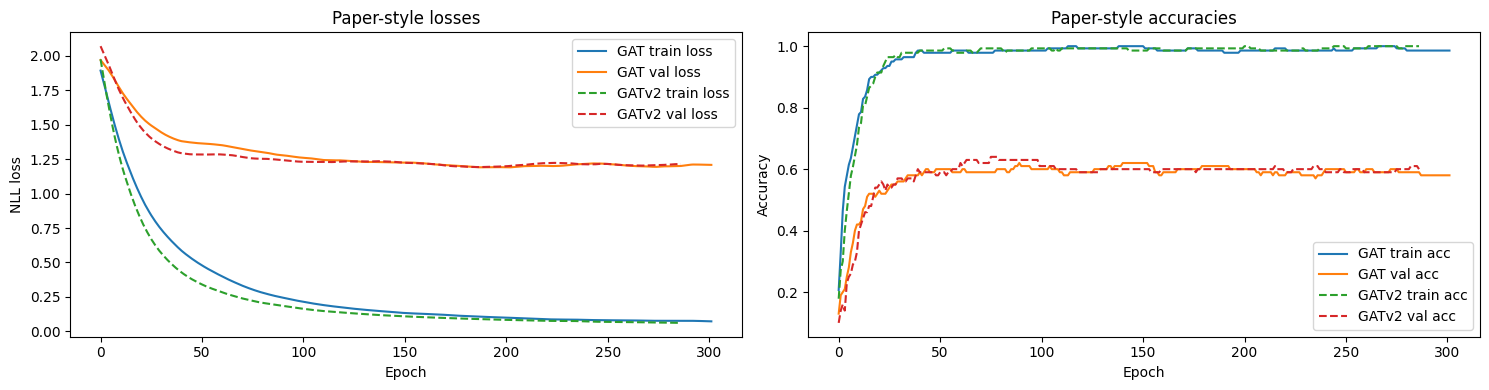

In [14]:
from pathlib import Path
import sys
import copy
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Locate repo root and import models from src/models.py (robust for local + Colab)
def find_repo_root_with_models() -> Path:
    cwd = Path.cwd().resolve()

    # 1) Fast path: current directory and all parents
    for p in [cwd, *cwd.parents]:
        if (p / "src" / "models.py").exists():
            return p

    # 2) Common notebook roots (Colab / mounted Drive / Kaggle)
    for root in [Path("/content"), Path("/content/drive/MyDrive"), Path("/kaggle/working")]:
        if not root.exists():
            continue
        for match in root.rglob("models.py"):
            if match.parent.name == "src":
                return match.parent.parent

    raise FileNotFoundError(
        "Could not locate src/models.py. Set repo_root manually to your project path."
    )

repo_root = find_repo_root_with_models()
print(f"Using repo root: {repo_root}")

if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from models import GAT_Model, GATv2_Model

if device.type != "cuda":
    raise RuntimeError("This experiment is configured for GPU. Please reconnect to a CUDA-enabled Colab runtime.")

print(f"Training on GPU: {torch.cuda.get_device_name(0)}")

from torch_geometric.utils import subgraph

# Use a smaller induced subgraph so custom src GATv2 fits in memory.
# (This implementation is O(N^2 * F) in memory due to dense node-pair tensors.)
# Budget is tied to currently free GPU memory with a safety margin.
BYTES_PER_FLOAT = 4
feat_dim = data.x.size(1)
free_bytes, total_bytes = torch.cuda.mem_get_info()
usable_bytes = int(free_bytes * 0.15)  # extra-conservative for src GATv2 pairwise tensors + optimizer state
TARGET_PAIR_TENSOR_GIB = usable_bytes / (1024 ** 3)
max_nodes_for_budget = int(((usable_bytes) / (2 * feat_dim * BYTES_PER_FLOAT)) ** 0.5)
TARGET_NODES = min(data.num_nodes, max_nodes_for_budget)

print(f"Free GPU memory: {free_bytes / (1024 ** 3):.2f} GiB / {total_bytes / (1024 ** 3):.2f} GiB")
print(f"Target pair-tensor budget: {TARGET_PAIR_TENSOR_GIB:.2f} GiB -> target nodes: {TARGET_NODES}")

full_train_idx = data.train_mask.nonzero(as_tuple=True)[0]
full_val_idx = data.val_mask.nonzero(as_tuple=True)[0]
full_test_idx = data.test_mask.nonzero(as_tuple=True)[0]
full_other_idx = (~(data.train_mask | data.val_mask | data.test_mask)).nonzero(as_tuple=True)[0]

def sample_indices(idx, k):
    if k <= 0:
        return idx[:0]
    if k >= idx.numel():
        return idx
    perm = torch.randperm(idx.numel(), device=idx.device)
    return idx[perm[:k]]

# Keep all train nodes, sample val/test/other to hit TARGET_NODES
keep_train = full_train_idx
remaining = max(0, TARGET_NODES - keep_train.numel())
keep_val = sample_indices(full_val_idx, min(full_val_idx.numel(), max(100, remaining // 3)))
remaining -= keep_val.numel()
keep_test = sample_indices(full_test_idx, min(full_test_idx.numel(), max(200, remaining // 2)))
remaining -= keep_test.numel()
keep_other = sample_indices(full_other_idx, max(0, remaining))

subset_nodes = torch.cat([keep_train, keep_val, keep_test, keep_other]).unique(sorted=True)
sub_edge_index, _ = subgraph(subset_nodes, data.edge_index, relabel_nodes=True)

features = data.x[subset_nodes].to(device)
labels = data.y[subset_nodes].to(device)
train_mask = data.train_mask[subset_nodes]
val_mask = data.val_mask[subset_nodes]
test_mask = data.test_mask[subset_nodes]

adj = to_dense_adj(sub_edge_index, max_num_nodes=features.size(0))[0].to(device)
adj = adj + torch.eye(adj.size(0), device=adj.device)

print(f"Using induced subgraph with {features.size(0)} nodes (from {data.num_nodes})")
print(f"Split sizes on subgraph -> train: {int(train_mask.sum())}, val: {int(val_mask.sum())}, test: {int(test_mask.sum())}")

# Paper-style hyperparameters from original GAT Cora setup
CFG = {
    "nhid": 8,
    "nheads": 8,
    "dropout": 0.6,
    "alpha": 0.2,
    "lr": 0.005,
    "weight_decay": 5e-4,
    "patience": 100,
    "max_epochs": 5000,
    "seed": 42,
}

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)

def evaluate(model):
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(features, adj)
            tr_loss = F.nll_loss(logits[train_mask], labels[train_mask]).item()
            va_loss = F.nll_loss(logits[val_mask], labels[val_mask]).item()
            te_loss = F.nll_loss(logits[test_mask], labels[test_mask]).item()

        tr_acc = (logits[train_mask].argmax(dim=1) == labels[train_mask]).float().mean().item()
        va_acc = (logits[val_mask].argmax(dim=1) == labels[val_mask]).float().mean().item()
        te_acc = (logits[test_mask].argmax(dim=1) == labels[test_mask]).float().mean().item()

    return {
        "train_loss": tr_loss, "val_loss": va_loss, "test_loss": te_loss,
        "train_acc": tr_acc, "val_acc": va_acc, "test_acc": te_acc,
    }

def run_paper_style(model_name, model_ctor):
    torch.manual_seed(CFG["seed"])
    torch.cuda.manual_seed_all(CFG["seed"])

    model = model_ctor(
        nfeat=dataset.num_features,
        nhid=CFG["nhid"],
        nclass=dataset.num_classes,
        dropout=CFG["dropout"],
        alpha=CFG["alpha"],
        nheads=CFG["nheads"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

    history = {
        "train_loss": [], "val_loss": [], "test_loss": [],
        "train_acc": [], "val_acc": [], "test_acc": []
    }

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    bad_counter = 0

    for epoch in range(CFG["max_epochs"]):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(features, adj)
            loss = F.nll_loss(logits[train_mask], labels[train_mask])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        stats = evaluate(model)
        for k in history:
            history[k].append(stats[k])

        # Match original early-stopping logic: reset patience if val acc improves OR val loss improves
        improved = (stats["val_acc"] >= best_val_acc) or (stats["val_loss"] <= best_val_loss)
        if improved:
            if (stats["val_acc"] >= best_val_acc) and (stats["val_loss"] <= best_val_loss):
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
            best_val_acc = max(best_val_acc, stats["val_acc"])
            best_val_loss = min(best_val_loss, stats["val_loss"])
            bad_counter = 0
        else:
            bad_counter += 1

        if bad_counter >= CFG["patience"]:
            break

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())

    # Final epoch metrics (last seen)
    final_stats = {k: history[k][-1] for k in history}

    # Best checkpoint metrics (paper-style selection)
    model.load_state_dict(best_state)
    best_stats = evaluate(model)

    print(f"\n{model_name}")
    print(f"Stopped at epoch {len(history['train_loss']) - 1}, best checkpoint epoch {best_epoch}")
    print(
        f"Best checkpoint -> train {best_stats['train_acc']:.3f}, "
        f"val {best_stats['val_acc']:.3f}, test {best_stats['test_acc']:.3f}"
    )
    print(
        f"Final epoch     -> train {final_stats['train_acc']:.3f}, "
        f"val {final_stats['val_acc']:.3f}, test {final_stats['test_acc']:.3f}"
    )

    return history, best_stats, final_stats

gat_hist, gat_best, gat_final = run_paper_style("GAT_Model (src/models.py)", GAT_Model)

import gc
gc.collect()
torch.cuda.empty_cache()

gatv2_hist = None
gatv2_best = None
gatv2_final = None
try:
    gatv2_hist, gatv2_best, gatv2_final = run_paper_style("GATv2_Model (src/models.py)", GATv2_Model)
except torch.cuda.OutOfMemoryError:
    torch.cuda.empty_cache()
    print("GATv2 still OOM with current subgraph size. Reduce TARGET_PAIR_TENSOR_GIB or rerun on a larger GPU.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(gat_hist["train_loss"], label="GAT train loss")
axes[0].plot(gat_hist["val_loss"], label="GAT val loss")
if gatv2_hist is not None:
    axes[0].plot(gatv2_hist["train_loss"], label="GATv2 train loss", linestyle="--")
    axes[0].plot(gatv2_hist["val_loss"], label="GATv2 val loss", linestyle="--")
axes[0].set_title("Paper-style losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL loss")
axes[0].legend()

axes[1].plot(gat_hist["train_acc"], label="GAT train acc")
axes[1].plot(gat_hist["val_acc"], label="GAT val acc")
if gatv2_hist is not None:
    axes[1].plot(gatv2_hist["train_acc"], label="GATv2 train acc", linestyle="--")
    axes[1].plot(gatv2_hist["val_acc"], label="GATv2 val acc", linestyle="--")
axes[1].set_title("Paper-style accuracies")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Official implementation comparison (PyG): `GATConv` vs `GATv2Conv`

This section uses the official PyTorch Geometric operators (not custom `src/models.py`) with matched hyperparameters and paper-style early stopping.

- Same Cora public split (`train/val/test` masks)
- Same optimizer and hyperparameters
- Same training protocol
- Only difference: `GATConv` vs `GATv2Conv`

Training on GPU: NVIDIA L4

GAT (PyG GATConv)
Stopped at epoch 158, best checkpoint epoch 29
Best checkpoint -> train 0.986, val 0.820, test 0.833
Final epoch     -> train 1.000, val 0.780, test 0.804

GATv2 (PyG GATv2Conv)
Stopped at epoch 162, best checkpoint epoch 27
Best checkpoint -> train 0.986, val 0.812, test 0.832
Final epoch     -> train 1.000, val 0.768, test 0.797


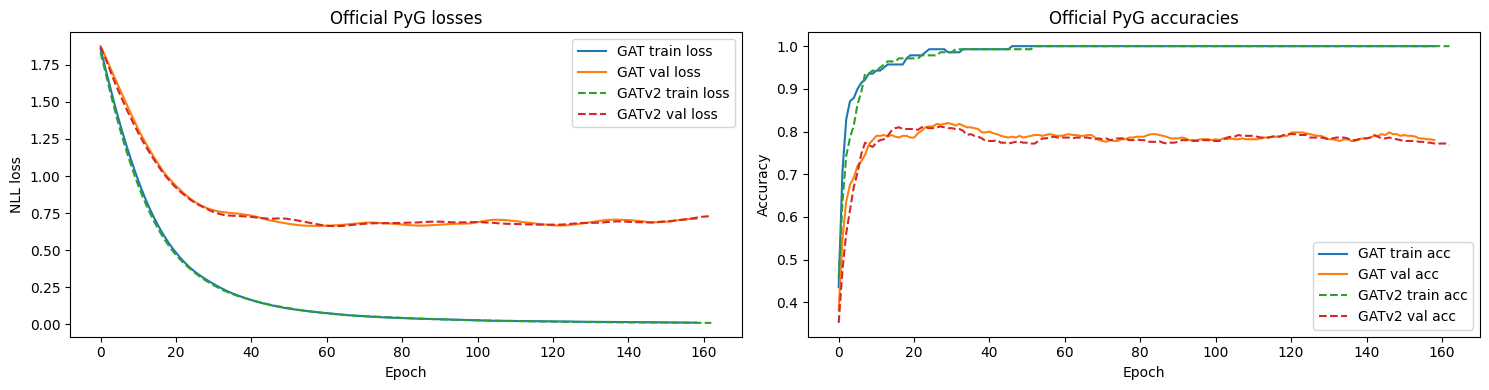

In [15]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GATConv, GATv2Conv

if device.type != "cuda":
    raise RuntimeError("Please connect to a GPU runtime.")

print(f"Training on GPU: {torch.cuda.get_device_name(0)}")

data = data.to(device)

CFG = {
    "hidden": 8,
    "heads": 8,
    "dropout": 0.6,
    "lr": 0.005,
    "weight_decay": 5e-4,
    "patience": 100,
    "max_epochs": 5000,
    "seed": 42,
}

class OfficialAttnNet(nn.Module):
    def __init__(self, conv_cls, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.conv1 = conv_cls(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = conv_cls(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)

def eval_stats(model):
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(data.x, data.edge_index)
            tr_loss = F.nll_loss(logits[data.train_mask], data.y[data.train_mask]).item()
            va_loss = F.nll_loss(logits[data.val_mask], data.y[data.val_mask]).item()
            te_loss = F.nll_loss(logits[data.test_mask], data.y[data.test_mask]).item()

        tr_acc = (logits[data.train_mask].argmax(dim=1) == data.y[data.train_mask]).float().mean().item()
        va_acc = (logits[data.val_mask].argmax(dim=1) == data.y[data.val_mask]).float().mean().item()
        te_acc = (logits[data.test_mask].argmax(dim=1) == data.y[data.test_mask]).float().mean().item()

    return {
        "train_loss": tr_loss, "val_loss": va_loss, "test_loss": te_loss,
        "train_acc": tr_acc, "val_acc": va_acc, "test_acc": te_acc,
    }

def run_official(model_name, conv_cls):
    torch.manual_seed(CFG["seed"])
    torch.cuda.manual_seed_all(CFG["seed"])

    model = OfficialAttnNet(
        conv_cls=conv_cls,
        in_channels=dataset.num_features,
        hidden_channels=CFG["hidden"],
        out_channels=dataset.num_classes,
        heads=CFG["heads"],
        dropout=CFG["dropout"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

    history = {k: [] for k in ["train_loss", "val_loss", "test_loss", "train_acc", "val_acc", "test_acc"]}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    best_epoch = 0
    bad_counter = 0

    for epoch in range(CFG["max_epochs"]):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(data.x, data.edge_index)
            loss = F.nll_loss(logits[data.train_mask], data.y[data.train_mask])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        stats = eval_stats(model)
        for k in history:
            history[k].append(stats[k])

        improved = (stats["val_acc"] >= best_val_acc) or (stats["val_loss"] <= best_val_loss)
        if improved:
            if (stats["val_acc"] >= best_val_acc) and (stats["val_loss"] <= best_val_loss):
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
            best_val_acc = max(best_val_acc, stats["val_acc"])
            best_val_loss = min(best_val_loss, stats["val_loss"])
            bad_counter = 0
        else:
            bad_counter += 1

        if bad_counter >= CFG["patience"]:
            break

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())

    final_stats = {k: history[k][-1] for k in history}
    model.load_state_dict(best_state)
    best_stats = eval_stats(model)

    print(f"\n{model_name}")
    print(f"Stopped at epoch {len(history['train_loss']) - 1}, best checkpoint epoch {best_epoch}")
    print(f"Best checkpoint -> train {best_stats['train_acc']:.3f}, val {best_stats['val_acc']:.3f}, test {best_stats['test_acc']:.3f}")
    print(f"Final epoch     -> train {final_stats['train_acc']:.3f}, val {final_stats['val_acc']:.3f}, test {final_stats['test_acc']:.3f}")

    return history, best_stats, final_stats

gat_hist_official, gat_best_official, gat_final_official = run_official("GAT (PyG GATConv)", GATConv)
gatv2_hist_official, gatv2_best_official, gatv2_final_official = run_official("GATv2 (PyG GATv2Conv)", GATv2Conv)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(gat_hist_official["train_loss"], label="GAT train loss")
axes[0].plot(gat_hist_official["val_loss"], label="GAT val loss")
axes[0].plot(gatv2_hist_official["train_loss"], label="GATv2 train loss", linestyle="--")
axes[0].plot(gatv2_hist_official["val_loss"], label="GATv2 val loss", linestyle="--")
axes[0].set_title("Official PyG losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL loss")
axes[0].legend()

axes[1].plot(gat_hist_official["train_acc"], label="GAT train acc")
axes[1].plot(gat_hist_official["val_acc"], label="GAT val acc")
axes[1].plot(gatv2_hist_official["train_acc"], label="GATv2 train acc", linestyle="--")
axes[1].plot(gatv2_hist_official["val_acc"], label="GATv2 val acc", linestyle="--")
axes[1].set_title("Official PyG accuracies")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Multi-seed check (official PyG) to test if differences are real

Single runs can look identical by chance. This cell runs multiple seeds and reports mean/std for best-checkpoint and final-epoch test accuracy for both models.

In [ ]:
import numpy as np
import copy
import torch
import torch.nn.functional as F

# Reuse OfficialAttnNet, data, and device from the previous cell.
MS_CFG = {
    "hidden": 8,
    "heads": 8,
    "dropout": 0.6,
    "lr": 0.005,
    "weight_decay": 5e-4,
    "patience": 100,
    "max_epochs": 2000,
}
SEEDS = list(range(10))

use_amp = device.type == "cuda"

def eval_model(model):
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(data.x, data.edge_index)
        test_acc = (logits[data.test_mask].argmax(dim=1) == data.y[data.test_mask]).float().mean().item()
        val_acc = (logits[data.val_mask].argmax(dim=1) == data.y[data.val_mask]).float().mean().item()
    return val_acc, test_acc

def run_one_seed(conv_cls, seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = OfficialAttnNet(
        conv_cls=conv_cls,
        in_channels=dataset.num_features,
        hidden_channels=MS_CFG["hidden"],
        out_channels=dataset.num_classes,
        heads=MS_CFG["heads"],
        dropout=MS_CFG["dropout"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=MS_CFG["lr"], weight_decay=MS_CFG["weight_decay"])
    scaler = torch.amp.GradScaler(device="cuda", enabled=use_amp)

    best_state = None
    best_val = -1.0
    best_epoch = 0
    bad_counter = 0

    for epoch in range(MS_CFG["max_epochs"]):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(data.x, data.edge_index)
            loss = F.nll_loss(logits[data.train_mask], data.y[data.train_mask])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        val_acc, _ = eval_model(model)

        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            bad_counter = 0
        else:
            bad_counter += 1

        if bad_counter >= MS_CFG["patience"]:
            break

    final_val, final_test = eval_model(model)

    model.load_state_dict(best_state)
    best_val_ckpt, best_test_ckpt = eval_model(model)

    return {
        "best_epoch": best_epoch,
        "best_val": best_val_ckpt,
        "best_test": best_test_ckpt,
        "final_val": final_val,
        "final_test": final_test,
    }

results = {"gat": [], "gatv2": []}

for seed in SEEDS:
    gat_res = run_one_seed(GATConv, seed)
    gatv2_res = run_one_seed(GATv2Conv, seed)
    results["gat"].append(gat_res)
    results["gatv2"].append(gatv2_res)
    print(
        f"Seed {seed:02d} | "
        f"GAT best_test={gat_res['best_test']:.4f}, final_test={gat_res['final_test']:.4f} | "
        f"GATv2 best_test={gatv2_res['best_test']:.4f}, final_test={gatv2_res['final_test']:.4f}"
    )

def summarize(model_key, metric):
    vals = np.array([r[metric] for r in results[model_key]], dtype=np.float64)
    return vals.mean(), vals.std(ddof=1)

for metric in ["best_test", "final_test", "best_val", "final_val"]:
    gat_m, gat_s = summarize("gat", metric)
    v2_m, v2_s = summarize("gatv2", metric)
    print(f"\n{metric}:")
    print(f"  GAT   : {gat_m:.4f} ± {gat_s:.4f}")
    print(f"  GATv2 : {v2_m:.4f} ± {v2_s:.4f}")
    print(f"  Delta (GATv2 - GAT): {v2_m - gat_m:+.4f}")